# De Jure EDA

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [2]:
DATA_PATH = Path("../data/raw/country_year_final_panel_full_new.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full_new.csv")

df = pd.read_csv(DATA_PATH)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_",
)

rule_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]
id_cols = [c for c in ["COUNTRY", "iso3", "year"] if c in df.columns]

print(f"Loaded: {DATA_PATH}")
print(f"Panel shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"ID columns: {id_cols}")
print(f"Rule columns: {len(rule_cols):,}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")

df.head()

Loaded: ../data/raw/country_year_final_panel_full_new.csv
Panel shape: 8,580 rows x 742 columns
ID columns: ['COUNTRY', 'iso3', 'year']
Rule columns: 730
Years: 1894-2025


,Unnamed: 0,COUNTRY,iso3,year,dj_expression,wdj_expression,wdj_citizen,wdj_intermediaries,wdj_press,wdj_govprot,wdj_restriction,wdj_obligation,C_DISINFO_GEN,I_DISINFO_GEN,P_DISINFO_GEN,C_DISINFO_GEN_DIGI,I_DISINFO_GEN_DIGI,P_DISINFO_GEN_DIGI,C_DISINFO_GEN_CRISIS,I_DISINFO_GEN_CRISIS,P_DISINFO_GEN_CRISIS,C_MALINFO_GEN,I_MALINFO_GEN,P_MALINFO_GEN,C_MALINFO_GEN_DIGI,I_MALINFO_GEN_DIGI,P_MALINFO_GEN_DIGI,C_MALINFO_GEN_CRISIS,I_MALINFO_GEN_CRISIS,P_MALINFO_GEN_CRISIS,C_MISINFO_GEN,I_MISINFO_GEN,P_MISINFO_GEN,C_MISINFO_GEN_DIGI,I_MISINFO_GEN_DIGI,P_MISINFO_GEN_DIGI,C_MISINFO_GEN_CRISIS,I_MISINFO_GEN_CRISIS,P_MISINFO_GEN_CRISIS,C_DISINFO_HATE,I_DISINFO_HATE,P_DISINFO_HATE,C_DISINFO_HATE_DIGI,I_DISINFO_HATE_DIGI,P_DISINFO_HATE_DIGI,C_DISINFO_HATE_CRISIS,I_DISINFO_HATE_CRISIS,P_DISINFO_HATE_CRISIS,C_DISINFO_HEALTHOFF,I_DISINFO_HEALTHOFF,P_DISINFO_HEALTHOFF,C_DISINFO_HEALTHOFF_DIGI,I_DISINFO_HEALTHOFF_DIGI,P_DISINFO_HEALTHOFF_DIGI,C_DISINFO_HEALTHOFF_CRISIS,I_DISINFO_HEALTHOFF_CRISIS,P_DISINFO_HEALTHOFF_CRISIS,C_DISINFO_LIFE,I_DISINFO_LIFE,P_DISINFO_LIFE,...,C_MISINFO_UNITY_DIGI,I_MISINFO_UNITY_DIGI,P_MISINFO_UNITY_DIGI,C_MISINFO_UNITY_CRISIS,I_MISINFO_UNITY_CRISIS,P_MISINFO_UNITY_CRISIS,GOV_CENSOR,GOV_CENSOR_CRISIS,GOV_NOWARRANT,GOV_NOWARRANT_CRISIS,GOV_OVERSIGHT,GOV_OVERSIGHT_CRISIS,GOV_REGULATOR,GOV_REGULATOR_CRISIS,GOV_WARRANT,GOV_WARRANT_CRISIS,REG_RULES,REG_RULES_CRISIS,IM_DAILY,IM_DAILY_CRISIS,IM_PUBINTEREST,IM_PUBINTEREST_CRISIS,IM_EMERGENCY,IM_EMERGENCY_CRISIS,IM_PREVENTION,IM_PREVENTION_CRISIS,IM_CORRECT,IM_CORRECT_CRISIS,IM_DATA,IM_DATA_CRISIS,IM_DEPLATFORM,IM_DEPLATFORM_CRISIS,IM_FUNDING,IM_FUNDING_CRISIS,IM_LICENSE,IM_LICENSE_CRISIS,IM_OVERSIGHT,IM_OVERSIGHT_CRISIS,IM_REPORT,IM_REPORT_CRISIS,PRESS_CORRECT,PRESS_CORRECT_CRISIS,PRESS_FUNDING,PRESS_FUNDING_CRISIS,PRESS_LICENSE,PRESS_LICENSE_CRISIS,PRESS_OVERSIGHT,PRESS_OVERSIGHT_CRISIS,PRESS_REPORT,PRESS_REPORT_CRISIS,APPEAL_NONREG,APPEAL_NONREG_CRISIS,APPEAL_REG,APPEAL_REG_CRISIS,EXEMPTION_LEG,EXEMPTION_LEG_CRISIS,EXEMPTION_SEPLEG,EXEMPTION_SEPLEG_CRISIS,LAWSUIT,LAWSUIT_CRISIS
0,1,ASEAN,ASEAN,1894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,ASEAN,ASEAN,1895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,ASEAN,ASEAN,1896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,ASEAN,ASEAN,1897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,ASEAN,ASEAN,1898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
allowed_rule_values = {-1, 0, 1}

rule_values = pd.Series(
    df[rule_cols].to_numpy().ravel(),
    name="value",
).dropna()

rule_value_counts = (
    rule_values
    .value_counts()
    .sort_index()
    .rename_axis("value")
    .reset_index(name="cell_count")
)

observed_rule_values = set(rule_value_counts["value"].tolist())
unexpected_rule_values = sorted(observed_rule_values - allowed_rule_values)

columns_with_unexpected_values = []
for col in rule_cols:
    col_values = set(df[col].dropna().unique().tolist())
    unexpected = sorted(col_values - allowed_rule_values)
    if unexpected:
        columns_with_unexpected_values.append({
            "column": col,
            "unexpected_values": unexpected,
        })

validation_summary = pd.DataFrame({
    "check": [
        "rule columns identified",
        "observed rule values",
        "unexpected values outside {-1, 0, 1}",
        "columns with unexpected values",
    ],
    "result": [
        len(rule_cols),
        sorted(observed_rule_values),
        unexpected_rule_values,
        len(columns_with_unexpected_values),
    ],
})

display(validation_summary)
display(rule_value_counts)

assert not unexpected_rule_values, f"Unexpected rule values found: {unexpected_rule_values}"
assert not columns_with_unexpected_values, columns_with_unexpected_values[:10]

,check,result
0,rule columns identified,730
1,observed rule values,"[-1, 0, 1]"
2,"unexpected values outside {-1, 0, 1}",[]
3,columns with unexpected values,0


,value,cell_count
0,-1,3983
1,0,6246609
2,1,12808


## Topical Trends

Track active rule coverage by actor family over time.

In [4]:
citizen_cols = [c for c in rule_cols if c.startswith("C_")]
press_cols = [c for c in rule_cols if c.startswith("P_")]
press_obligation_cols = [c for c in rule_cols if c.startswith("PRESS_")]
internet_cols = [c for c in rule_cols if c.startswith("I_")]
intermediary_cols = [c for c in rule_cols if c.startswith("IM_")]
gov_prot_cols = [c for c in rule_cols if c.startswith(("APPEAL_", "EXEMPTION_", "LAWSUIT_", "REG_"))]

trend_groups = {
    "Citizens (C_)": citizen_cols,
    "Press (P_ + PRESS_)": press_cols + press_obligation_cols,
    "Internet (I_ + IM_)": internet_cols + intermediary_cols,
    "Government Protections": gov_prot_cols,
}

topical_group_summary = pd.DataFrame({
    "group": trend_groups.keys(),
    "rule_columns": [len(cols) for cols in trend_groups.values()],
})

topical_group_summary

,group,rule_columns
0,Citizens (C_),226
1,Press (P_ + PRESS_),235
2,Internet (I_ + IM_),247
3,Government Protections,11


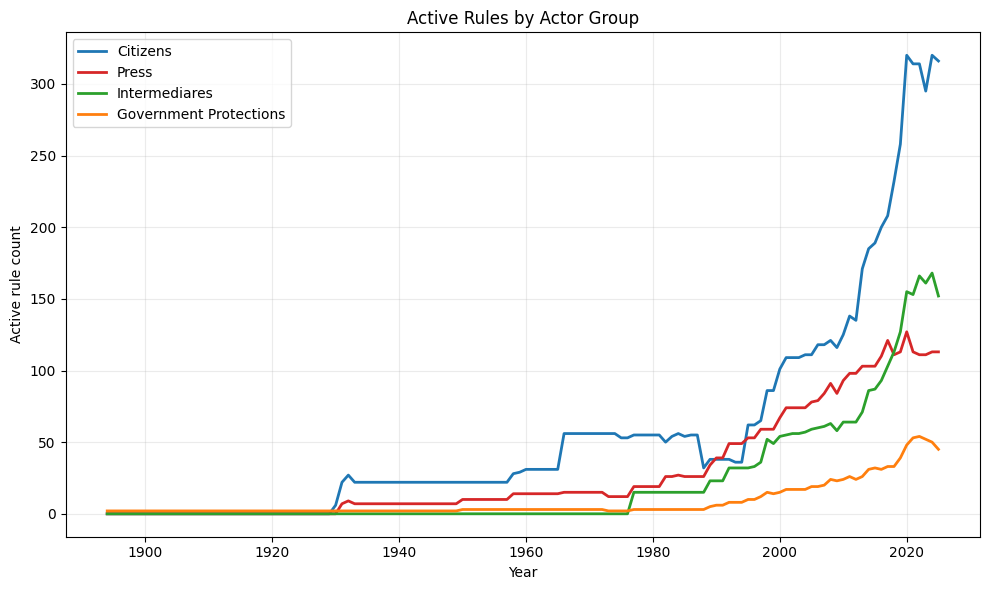

,year,Citizens (C_),Press (P_ + PRESS_),Internet (I_ + IM_),Government Protections
122,2016,200,110,93,31
123,2017,208,121,103,33
124,2018,232,111,113,33
125,2019,258,113,127,39
126,2020,320,127,155,48
127,2021,314,113,153,53
128,2022,314,111,166,54
129,2023,295,111,161,52
130,2024,320,113,168,50
131,2025,316,113,152,45


In [5]:
yearly_active_rules = pd.DataFrame({"year": df["year"]})

for group_name, cols in trend_groups.items():
    yearly_active_rules[group_name] = df[cols].fillna(0).ne(0).sum(axis=1)

yearly_active_rules = (
    yearly_active_rules
    .groupby("year", as_index=False)
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Citizens (C_)"],
    label="Citizens",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Press (P_ + PRESS_)"],
    label="Press",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Internet (I_ + IM_)"],
    label="Intermediares",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Government Protections"],
    label="Government Protections",
    color="#ff7f0e",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Active Rules by Actor Group")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_active_rules.tail(10)

## Active Rules by Condition

Track active rule coverage by condition type (_CRISIS, _DIGI, and general rules).

In [6]:
crisis_cols = [c for c in rule_cols if "_CRISIS" in c]
digi_cols = [c for c in rule_cols if "_DIGI" in c]
general_cols = [c for c in rule_cols if "_CRISIS" not in c and "_DIGI" not in c]

condition_groups = {
    "Crisis (_CRISIS)": crisis_cols,
    "Digital (_DIGI)": digi_cols,
    "General": general_cols,
}

condition_group_summary = pd.DataFrame({
    "condition": condition_groups.keys(),
    "rule_columns": [len(cols) for cols in condition_groups.values()],
})

condition_group_summary

,condition,rule_columns
0,Crisis (_CRISIS),252
1,Digital (_DIGI),225
2,General,253


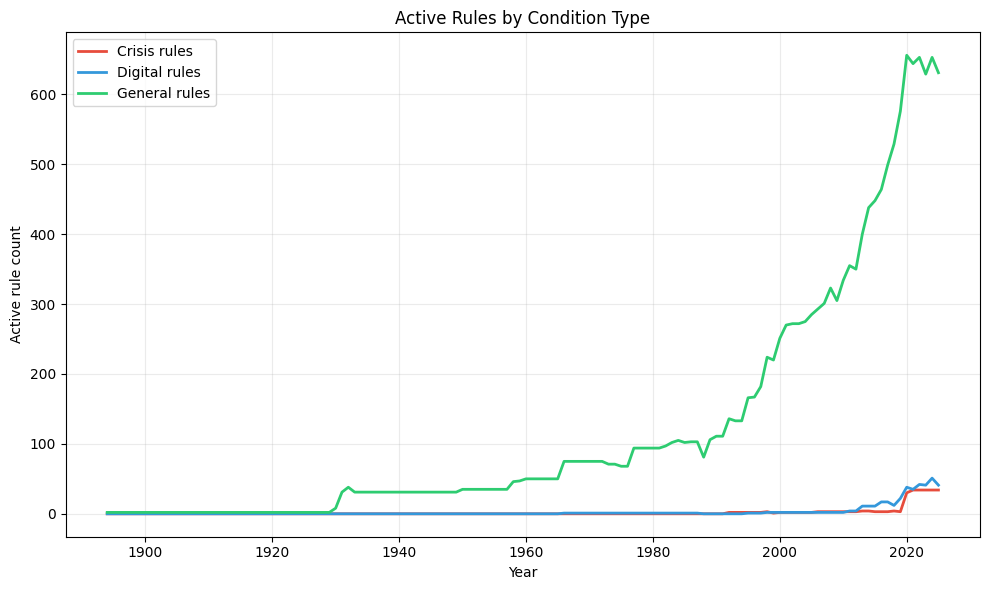

,year,Crisis (_CRISIS),Digital (_DIGI),General
122,2016,3,17,464
123,2017,3,17,499
124,2018,4,12,529
125,2019,3,22,576
126,2020,30,38,656
127,2021,34,35,644
128,2022,34,42,653
129,2023,34,41,629
130,2024,34,51,653
131,2025,34,41,631


In [7]:
yearly_condition_active_rules = pd.DataFrame({"year": df["year"]})

for condition_name, cols in condition_groups.items():
    yearly_condition_active_rules[condition_name] = df[cols].fillna(0).ne(0).sum(axis=1)

yearly_condition_active_rules = (
    yearly_condition_active_rules
    .groupby("year", as_index=False)
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_condition_active_rules["year"],
    yearly_condition_active_rules["Crisis (_CRISIS)"],
    label="Crisis rules",
    color="#e74c3c",
    linewidth=2,
)
plt.plot(
    yearly_condition_active_rules["year"],
    yearly_condition_active_rules["Digital (_DIGI)"],
    label="Digital rules",
    color="#3498db",
    linewidth=2,
)
plt.plot(
    yearly_condition_active_rules["year"],
    yearly_condition_active_rules["General"],
    label="General rules",
    color="#2ecc71",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Active Rules by Condition Type")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_condition_active_rules.tail(10)

## Crisis and Digital Rules by Country in 2025

List of all _CRISIS and _DIGI rules with the countries that have them active.

In [8]:
# Get all crisis and digital rule columns
crisis_digi_cols = [c for c in rule_cols if "_CRISIS" in c or "_DIGI" in c]

# Filter for 2025 data
df_2025 = df[df["year"] == 2025]

# Create a list to store results
rule_country_list = []

for col in crisis_digi_cols:
    # Get countries where this rule is active (non-zero)
    active_countries = df_2025[df_2025[col].fillna(0) != 0]["COUNTRY"].tolist()

    if active_countries:  # Only include rules that are active somewhere
        rule_country_list.append({
            "Rule": col,
            "Type": "Crisis" if "_CRISIS" in col else "Digital",
            "Active Countries": ", ".join(sorted(active_countries)),
            "Country Count": len(active_countries)
        })

# Convert to DataFrame and sort by country count (descending)
rule_country_df = pd.DataFrame(rule_country_list)
rule_country_df = rule_country_df.sort_values("Country Count", ascending=False).reset_index(drop=True)

# Display the results
print(f"Total crisis and digital rules: {len(crisis_digi_cols)}")
print(f"Rules with at least one active country in 2025: {len(rule_country_df)}")
print()

rule_country_df

Total crisis and digital rules: 477
Rules with at least one active country in 2025: 63



,Rule,Type,Active Countries,Country Count
0,C_MISINFO_GOVAFFAIRS_CRISIS,Crisis,"South Africa, Zimbabwe",2
1,C_EXPRESS_ORDER_DIGI,Digital,"Côte d""Ivoire, Nicaragua",2
2,C_EXPRESS_HATE_DIGI,Digital,"Côte d""Ivoire, Nicaragua",2
3,C_DISINFO_PUBHEALTH_CRISIS,Crisis,"Botswana, Eswatini",2
4,C_MISINFO_HEALTHOFF_CRISIS,Crisis,"Philippines, Zimbabwe",2
5,C_EXPRESS_OBSCENE_DIGI,Digital,"Côte d""Ivoire, Nicaragua",2
6,C_EXPRESS_LIFE_DIGI,Digital,"Côte d""Ivoire, Nicaragua",2
7,C_DISINFO_ORDER_DIGI,Digital,"Côte d""Ivoire, Nicaragua",2
8,C_MISINFO_PUBHEALTH_CRISIS,Crisis,"Eswatini, South Africa",2
9,GOV_CENSOR_CRISIS,Crisis,"Cambodia, Malaysia",2


In [9]:
# Crisis and Digital Rules Adoption Timeline (2000-2025)
# Track new rules introduced each year and cumulative totals

crisis_cols = [c for c in rule_cols if "_CRISIS" in c]
digi_cols = [c for c in rule_cols if "_DIGI" in c]

years = sorted(df['year'].unique())
years = [y for y in years if y >= 2000]

# Track which rules have been seen as active
seen_crisis_rules = set()
seen_digi_rules = set()

timeline_data = []

for year in years:
    year_df = df[df['year'] == year]

    # Current active crisis and digi rules this year
    active_crisis_this_year = set()
    active_digi_this_year = set()

    for rule in crisis_cols:
        if (year_df[rule].fillna(0) != 0).any():
            active_crisis_this_year.add(rule)

    for rule in digi_cols:
        if (year_df[rule].fillna(0) != 0).any():
            active_digi_this_year.add(rule)

    # New rules this year (not seen before)
    new_crisis_this_year = active_crisis_this_year - seen_crisis_rules
    new_digi_this_year = active_digi_this_year - seen_digi_rules

    # Update seen rules
    seen_crisis_rules.update(active_crisis_this_year)
    seen_digi_rules.update(active_digi_this_year)

    timeline_data.append({
        'Year': year,
        'New Crisis Rules': len(new_crisis_this_year),
        'New Digi Rules': len(new_digi_this_year),
        'Cumulative Crisis Rules': len(seen_crisis_rules),
        'Cumulative Digi Rules': len(seen_digi_rules)
    })

timeline_df = pd.DataFrame(timeline_data)
timeline_df

,Year,New Crisis Rules,New Digi Rules,Cumulative Crisis Rules,Cumulative Digi Rules
0,2000,2,2,2,2
1,2001,0,0,2,2
2,2002,0,0,2,2
3,2003,0,0,2,2
4,2004,0,0,2,2
5,2005,0,0,2,2
6,2006,0,0,2,2
7,2007,0,0,2,2
8,2008,0,0,2,2
9,2009,0,0,2,2


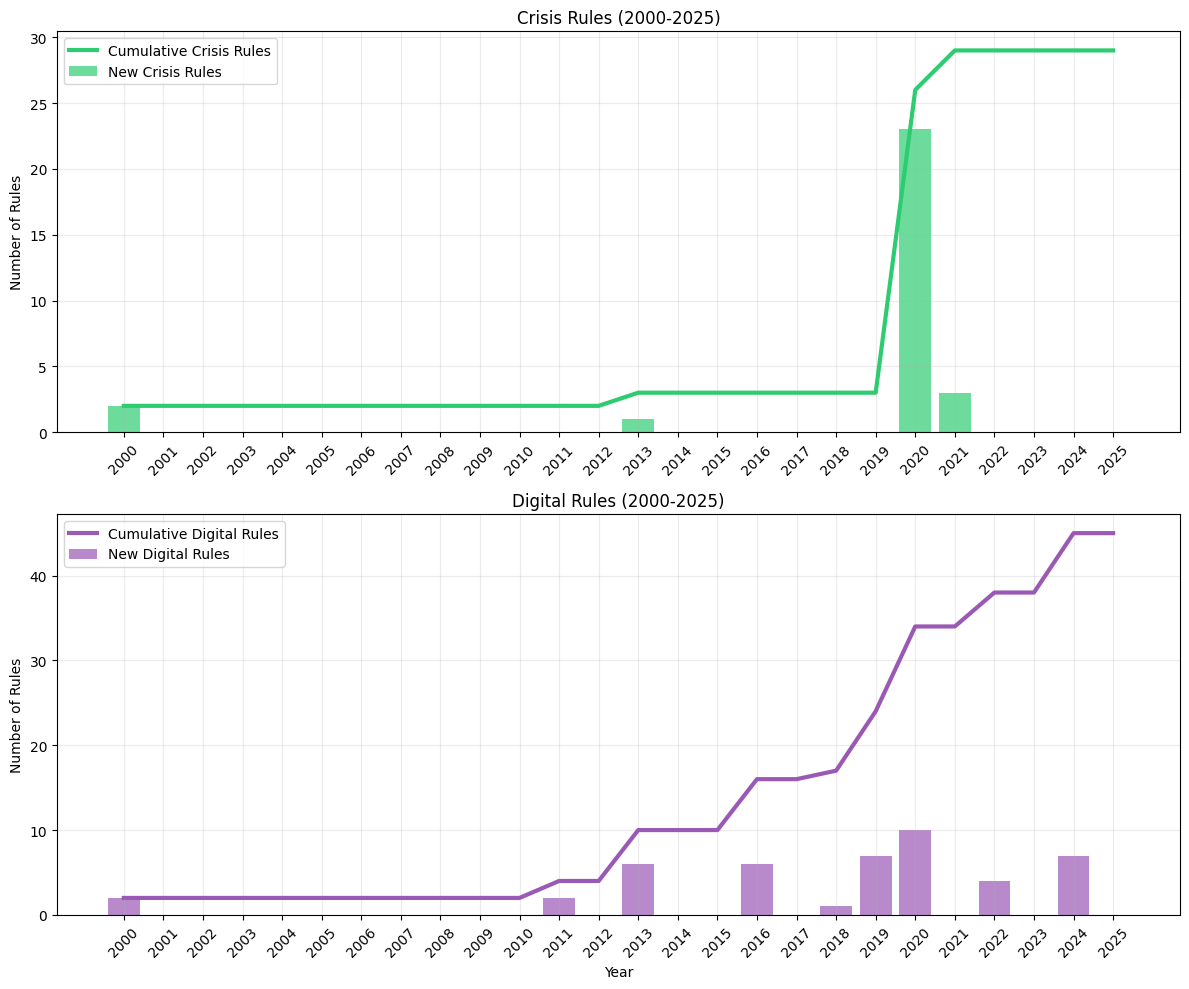

In [10]:
# Plot the crisis and digital rules adoption timeline
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Crisis rules plot
bars1 = ax1.bar(timeline_df['Year'], timeline_df['New Crisis Rules'], color='#2ecc71', alpha=0.7, label='New Crisis Rules', width=0.8)
line1, = ax1.plot(timeline_df['Year'], timeline_df['Cumulative Crisis Rules'], color='#2ecc71', linewidth=3, label='Cumulative Crisis Rules')
ax1.set_title('Crisis Rules (2000-2025)')
ax1.set_ylabel('Number of Rules')
ax1.grid(True, alpha=0.25)
ax1.legend(loc='upper left')
ax1.set_xticks(timeline_df['Year'])
ax1.set_xticklabels(timeline_df['Year'], rotation=45)

# Digital rules plot
bars2 = ax2.bar(timeline_df['Year'], timeline_df['New Digi Rules'], color='#9b59b6', alpha=0.7, label='New Digital Rules', width=0.8)
line2, = ax2.plot(timeline_df['Year'], timeline_df['Cumulative Digi Rules'], color='#9b59b6', linewidth=3, label='Cumulative Digital Rules')
ax2.set_title('Digital Rules (2000-2025)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Rules')
ax2.grid(True, alpha=0.25)
ax2.legend(loc='upper left')
ax2.set_xticks(timeline_df['Year'])
ax2.set_xticklabels(timeline_df['Year'], rotation=45)

plt.tight_layout()
plt.show()

## Rules with Most Growth 2000-2025

Rules that have shown the largest increase in country adoption between 2000 and 2025.

In [11]:
# Calculate growth in active countries for each rule between 2000 and 2025
df_2000 = df[df["year"] == 2000]
df_2025 = df[df["year"] == 2025]

rule_growth_list = []

for col in rule_cols:
    # Count active countries in 2000 and 2025
    active_2000 = (df_2000[col].fillna(0) != 0).sum()
    active_2025 = (df_2025[col].fillna(0) != 0).sum()

    # Calculate growth
    growth = active_2025 - active_2000

    # Only include rules that had some activity in at least one year
    if active_2000 > 0 or active_2025 > 0:
        rule_growth_list.append({
            "Rule": col,
            "Active Countries 2000": active_2000,
            "Active Countries 2025": active_2025,
            "Growth": growth,
            "Growth Rate": f"{((active_2025 / max(active_2000, 1)) - 1) * 100:.1f}%" if active_2000 > 0 else "New"
        })

# Convert to DataFrame and sort by growth (descending)
rule_growth_df = pd.DataFrame(rule_growth_list)
rule_growth_df = rule_growth_df.sort_values("Growth", ascending=False).reset_index(drop=True)

# Display summary
print(f"Total rules analyzed: {len(rule_cols)}")
print(f"Rules with activity in 2000 or 2025: {len(rule_growth_df)}")
print(f"Rules with positive growth: {len(rule_growth_df[rule_growth_df['Growth'] > 0])}")
print(f"Rules with negative growth: {len(rule_growth_df[rule_growth_df['Growth'] < 0])}")
print()

# Show top 10 growing rules
print("Top 10 rules by growth in active countries (2000-2025):")
print(rule_growth_df.head(10).to_string())

Total rules analyzed: 730
Rules with activity in 2000 or 2025: 211
Rules with positive growth: 177
Rules with negative growth: 9

Top 10 rules by growth in active countries (2000-2025):
                   Rule  Active Countries 2000  Active Countries 2025  Growth Growth Rate
0         GOV_REGULATOR                      4                     20      16      400.0%
1           GOV_WARRANT                      1                     15      14     1400.0%
2         GOV_OVERSIGHT                      2                     16      14      700.0%
3          IM_OVERSIGHT                      6                     18      12      200.0%
4         IM_PREVENTION                      3                     14      11      366.7%
5  C_DISINFO_REPUTATION                      3                     13      10      333.3%
6        C_EXPRESS_HATE                      4                     14      10      250.0%
7         IM_DEPLATFORM                      1                     11      10     1000.0%
8   

In [12]:
# Show rules with negative growth and their active countries
negative_growth_df = rule_growth_df[rule_growth_df['Growth'] < 0].copy()
negative_growth_df = negative_growth_df.sort_values("Growth", ascending=True).reset_index(drop=True)

print(f"Rules with negative growth (declining adoption) 2000-2025: {len(negative_growth_df)}")
print()

# Create detailed view with countries
detailed_negative_growth = []

for _, row in negative_growth_df.iterrows():
    rule_name = row['Rule']

    # Get countries active in 2000
    countries_2000 = df_2000[df_2000[rule_name].fillna(0) != 0]["COUNTRY"].tolist()
    countries_2000_str = ", ".join(sorted(countries_2000)) if countries_2000 else "None"

    # Get countries active in 2025
    countries_2025 = df_2025[df_2025[rule_name].fillna(0) != 0]["COUNTRY"].tolist()
    countries_2025_str = ", ".join(sorted(countries_2025)) if countries_2025 else "None"

    detailed_negative_growth.append({
        "Rule": rule_name,
        "Active Countries 2000": row['Active Countries 2000'],
        "Countries 2000": countries_2000_str,
        "Active Countries 2025": row['Active Countries 2025'],
        "Countries 2025": countries_2025_str,
        "Growth": row['Growth'],
        "Growth Rate": row['Growth Rate']
    })

detailed_negative_df = pd.DataFrame(detailed_negative_growth)
print(detailed_negative_df.to_string(index=False))

Rules with negative growth (declining adoption) 2000-2025: 9

                Rule  Active Countries 2000      Countries 2000  Active Countries 2025 Countries 2025  Growth Growth Rate
P_EXPRESS_CLASSIFIED                      2     Algeria, Poland                      0           None      -2     -100.0%
  I_EXPRESS_PROPERTY                      2 Azerbaijan, Uruguay                      1     Azerbaijan      -1      -50.0%
  P_EXPRESS_PROPERTY                      1             Uruguay                      0           None      -1     -100.0%
    P_EXPRESS_NATREP                      1           Venezuela                      0           None      -1     -100.0%
 P_EXPRESS_PUBHEALTH                      1              Poland                      0           None      -1     -100.0%
    P_DISINFO_NATSEC                      1             Algeria                      0           None      -1     -100.0%
  I_EXPRESS_GOVLEGIT                      1            Malaysia                     

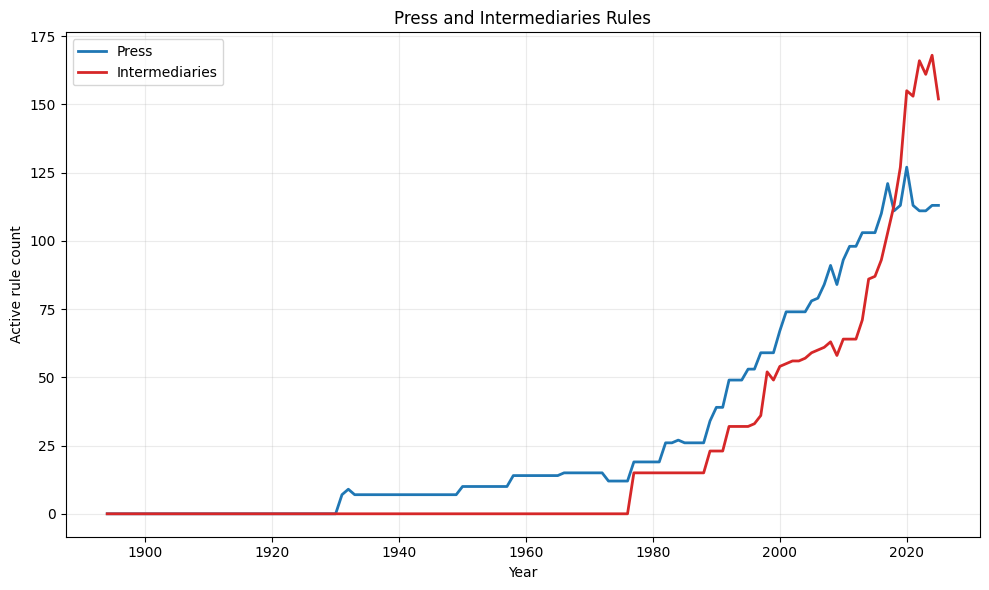

,year,Press (P_ + PRESS_),Internet (I_ + IM_)
122,2016,110,93
123,2017,121,103
124,2018,111,113
125,2019,113,127
126,2020,127,155
127,2021,113,153
128,2022,111,166
129,2023,111,161
130,2024,113,168
131,2025,113,152


In [13]:
plt.figure(figsize=(10, 6))
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Press (P_ + PRESS_)"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Internet (I_ + IM_)"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Press and Intermediaries Rules")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_active_rules[["year", "Press (P_ + PRESS_)", "Internet (I_ + IM_)"]].tail(10)

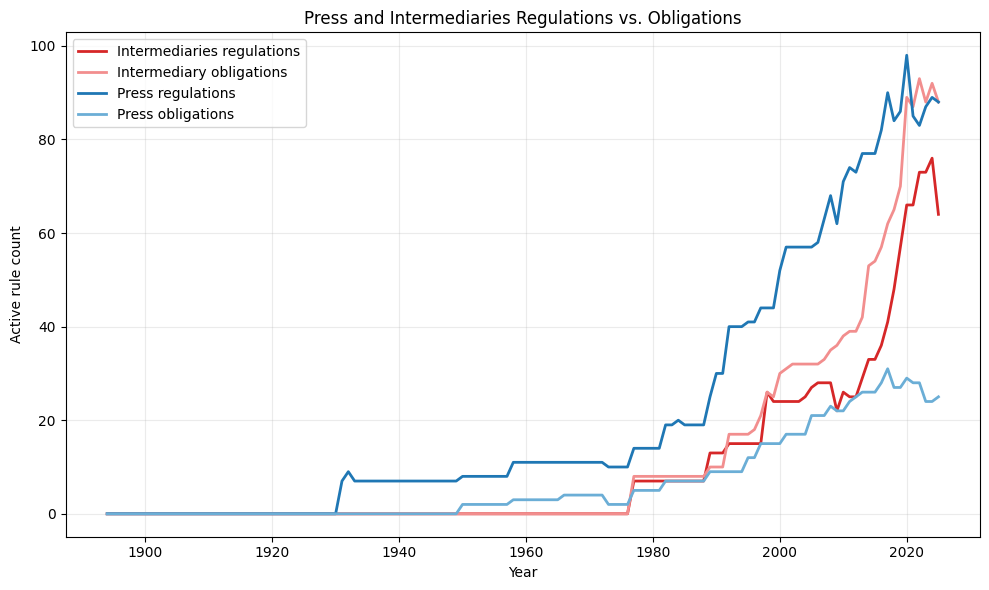

,year,I_,IM_,P_,PRESS_
122,2016,36,57,82,28
123,2017,41,62,90,31
124,2018,48,65,84,27
125,2019,57,70,86,27
126,2020,66,89,98,29
127,2021,66,87,85,28
128,2022,73,93,83,28
129,2023,73,88,87,24
130,2024,76,92,89,24
131,2025,64,88,88,25


In [14]:
yearly_family_active_rules = pd.DataFrame({
    "year": df["year"],
    "I_": df[internet_cols].fillna(0).ne(0).sum(axis=1),
    "IM_": df[intermediary_cols].fillna(0).ne(0).sum(axis=1),
    "P_": df[press_cols].fillna(0).ne(0).sum(axis=1),
    "PRESS_": df[press_obligation_cols].fillna(0).ne(0).sum(axis=1),
})

yearly_family_active_rules = (
    yearly_family_active_rules
    .groupby("year", as_index=False)
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["I_"],
    label="Intermediaries regulations",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["IM_"],
    label="Intermediary obligations",
    color="#f28e8e",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["P_"],
    label="Press regulations",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["PRESS_"],
    label="Press obligations",
    color="#6baed6",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Press and Intermediaries Regulations vs. Obligations")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_family_active_rules.tail(10)

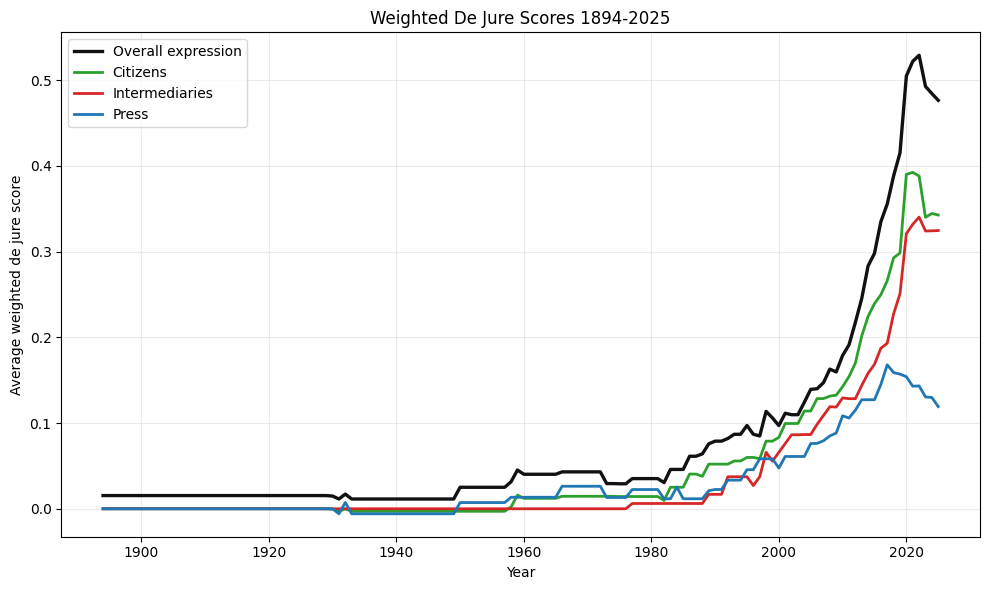

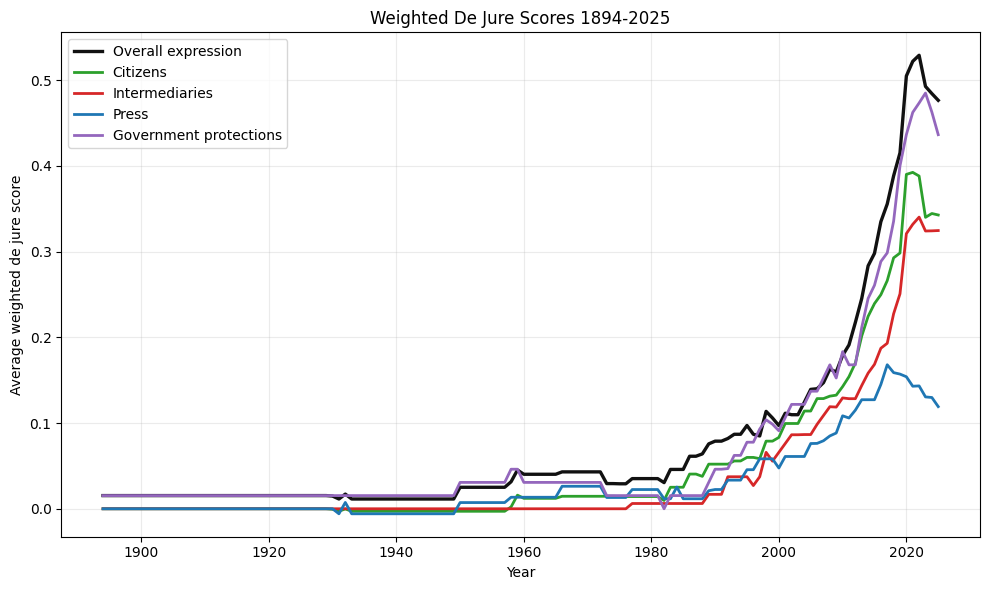

,year,wdj_expression,wdj_citizen,wdj_intermediaries,wdj_press,wdj_govprot
122,2016,0.334950,0.249742,0.187300,0.145031,0.288462
123,2017,0.355596,0.266153,0.193085,0.168036,0.298547
124,2018,0.388365,0.292753,0.227480,0.158848,0.335470
125,2019,0.415253,0.298388,0.250790,0.157139,0.400085
126,2020,0.504928,0.390131,0.320971,0.154046,0.436545
127,2021,0.522036,0.392489,0.331868,0.142984,0.462470
128,2022,0.529132,0.388191,0.340284,0.143340,0.473460
129,2023,0.492783,0.340044,0.324092,0.130513,0.485035
130,2024,0.484416,0.344505,0.324272,0.129829,0.462812
131,2025,0.476545,0.342766,0.324609,0.119188,0.436459


In [15]:
de_jure_score_cols = [
    "wdj_expression",
    "wdj_citizen",
    "wdj_intermediaries",
    "wdj_press",
    "wdj_govprot",
]

yearly_de_jure_scores = (
    df.groupby("year", as_index=False)[de_jure_score_cols]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_expression"],
    label="Overall expression",
    color="#111111",
    linewidth=2.4,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_citizen"],
    label="Citizens",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_intermediaries"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_press"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted De Jure Scores 1894-2025")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_expression"],
    label="Overall expression",
    color="#111111",
    linewidth=2.4,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_citizen"],
    label="Citizens",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_intermediaries"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_press"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_govprot"],
    label="Government protections",
    color="#9467bd",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted De Jure Scores 1894-2025")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_de_jure_scores.tail(10)

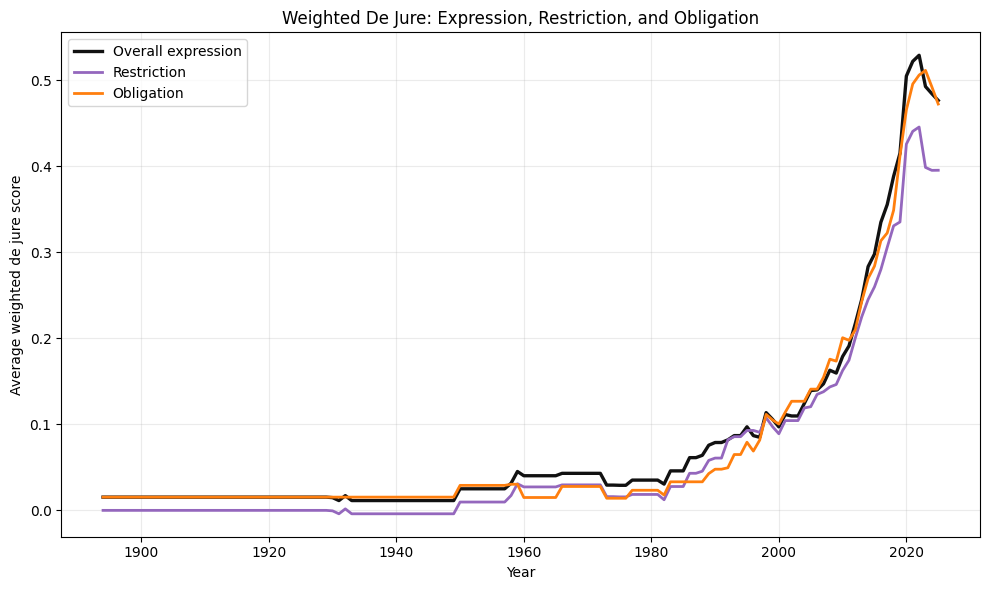

,year,wdj_expression,wdj_restriction,wdj_obligation
122,2016,0.334950,0.279968,0.313425
123,2017,0.355596,0.305865,0.322560
124,2018,0.388365,0.330796,0.348927
125,2019,0.415253,0.335315,0.412175
126,2020,0.504928,0.425774,0.465594
127,2021,0.522036,0.440688,0.495713
128,2022,0.529132,0.445694,0.506089
129,2023,0.492783,0.398744,0.511559
130,2024,0.484416,0.395325,0.492377
131,2025,0.476545,0.395424,0.472433


In [16]:
# Plot wdj_expression, wdj_restriction, and wdj_obligation
restriction_obligation_score_cols = [
    "wdj_expression",
    "wdj_restriction",
    "wdj_obligation",
]

yearly_restriction_obligation_scores = (
    df.groupby("year", as_index=False)[restriction_obligation_score_cols]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_restriction_obligation_scores["year"],
    yearly_restriction_obligation_scores["wdj_expression"],
    label="Overall expression",
    color="#111111",
    linewidth=2.4,
)
plt.plot(
    yearly_restriction_obligation_scores["year"],
    yearly_restriction_obligation_scores["wdj_restriction"],
    label="Restriction",
    color="#9467bd",
    linewidth=2,
)
plt.plot(
    yearly_restriction_obligation_scores["year"],
    yearly_restriction_obligation_scores["wdj_obligation"],
    label="Obligation",
    color="#ff7f0e",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted De Jure: Expression, Restriction, and Obligation")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_restriction_obligation_scores.tail(10)

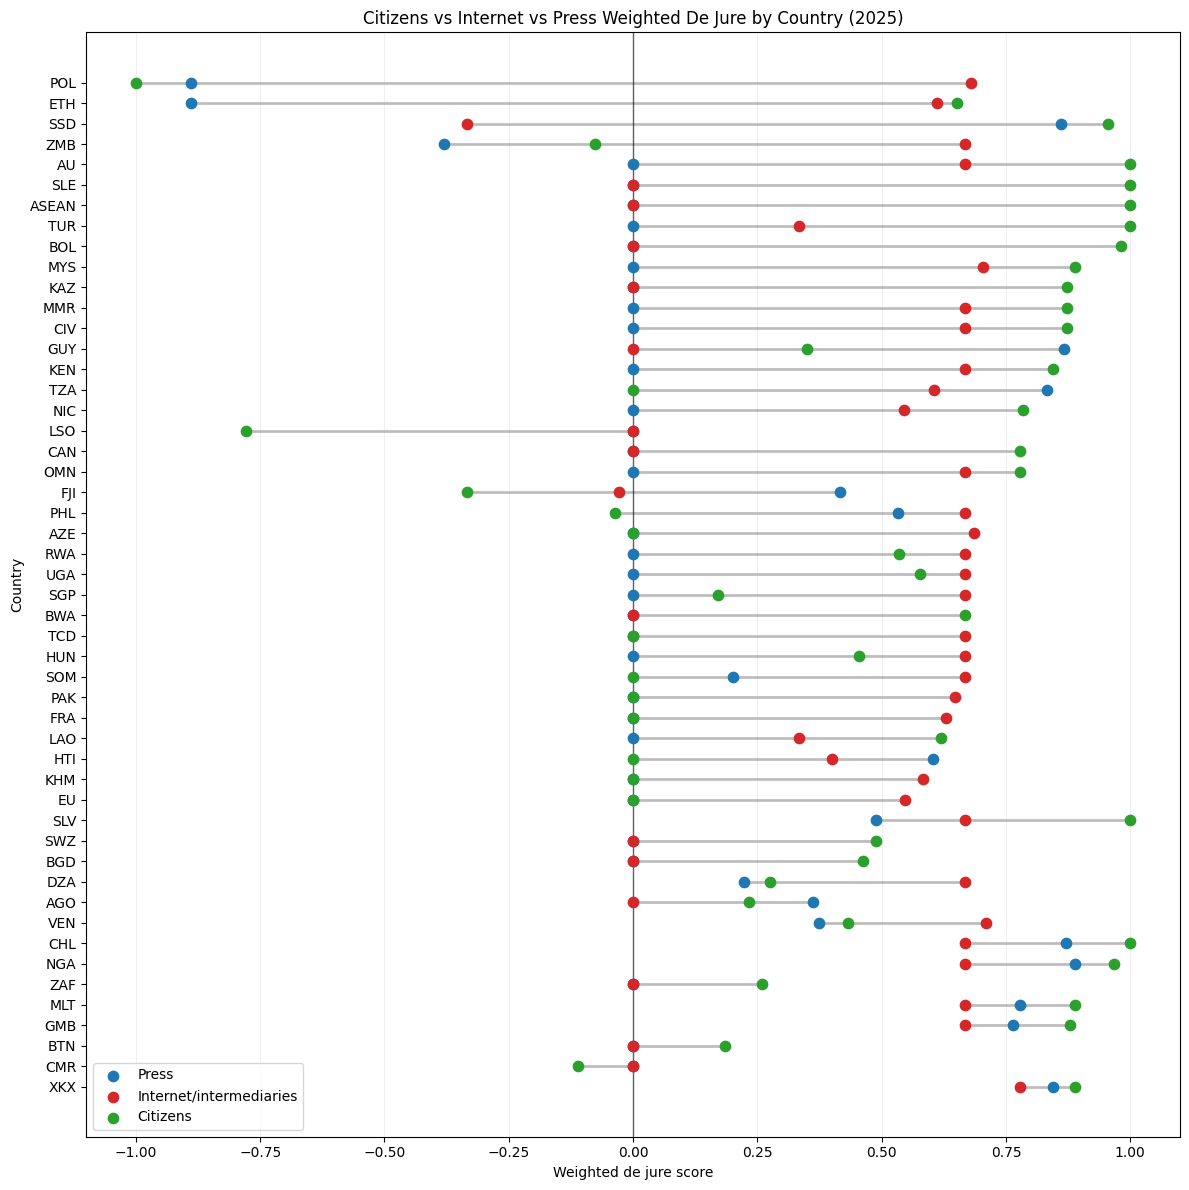

,COUNTRY,iso3,wdj_press,wdj_intermediaries,wdj_citizen,spread,active_rule_count_total
0,Kosovo,XKX,0.844444,0.777778,0.888889,0.111111,11
1,Cameroon,CMR,0.000000,0.000000,-0.111111,0.111111,9
2,Bhutan,BTN,0.000000,0.000000,0.185185,0.185185,9
3,The Gambia,GMB,0.763889,0.666667,0.878788,0.212121,21
4,Malta,MLT,0.777778,0.666667,0.888889,0.222222,9
5,South Africa,ZAF,0.000000,0.000000,0.259259,0.259259,4
6,Nigeria,NGA,0.888889,0.666667,0.968254,0.301587,18
7,Chile,CHL,0.870370,0.666667,1.000000,0.333333,14
8,Venezuela,VEN,0.374074,0.709402,0.432749,0.335328,56
9,Angola,AGO,0.361111,0.000000,0.232323,0.361111,19


In [17]:
plot_year = 2025

cip_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "wdj_citizen",
        "wdj_intermediaries",
        "wdj_press",
    ]]
    .dropna()
    .copy()
)

active_rule_count_total = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

cip_df["active_rule_count_total"] = active_rule_count_total

score_cols = ["wdj_citizen", "wdj_intermediaries", "wdj_press"]
cip_df = cip_df[(cip_df[score_cols] != 0).any(axis=1)].copy()
cip_df["spread"] = cip_df[score_cols].max(axis=1) - cip_df[score_cols].min(axis=1)

cip_df = cip_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(cip_df))

plt.figure(figsize=(12, 12))

for i, row in cip_df.iterrows():
    x_values = sorted([
        row["wdj_press"],
        row["wdj_intermediaries"],
        row["wdj_citizen"],
    ])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    cip_df["wdj_press"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press",
    zorder=3,
)
plt.scatter(
    cip_df["wdj_intermediaries"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet/intermediaries",
    zorder=3,
)
plt.scatter(
    cip_df["wdj_citizen"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, cip_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Citizens vs Internet vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

cip_df[[
    "COUNTRY",
    "iso3",
    "wdj_press",
    "wdj_intermediaries",
    "wdj_citizen",
    "spread",
    "active_rule_count_total",
]]

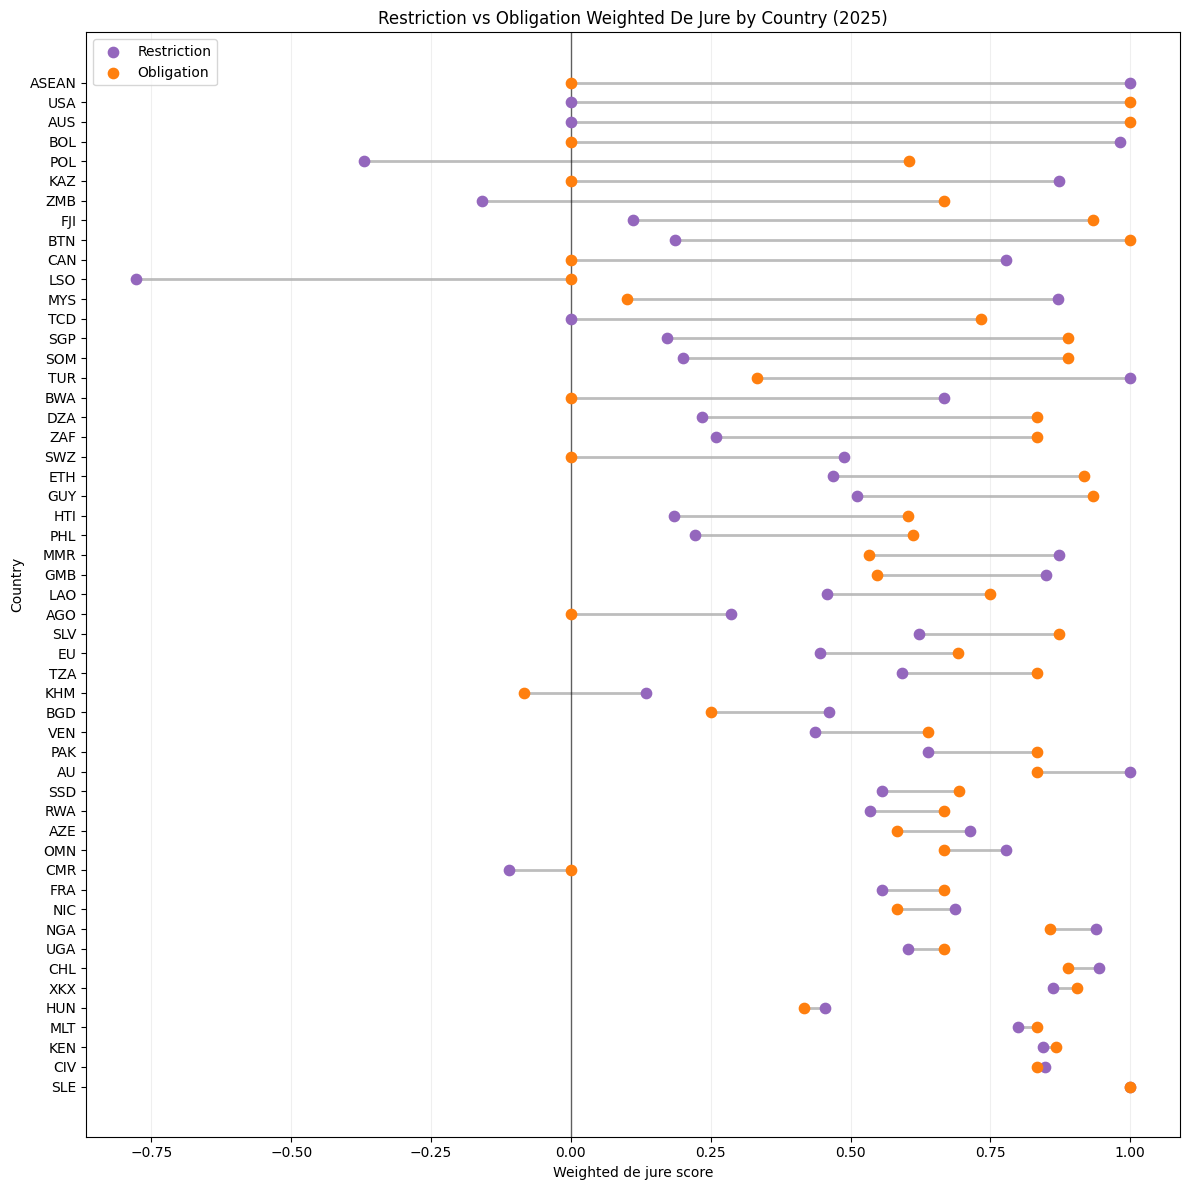

,COUNTRY,iso3,wdj_restriction,wdj_obligation,spread,active_rule_count_total
0,Sierra Leone,SLE,1.000000,1.000000,0.000000,7
1,"Côte d""Ivoire",CIV,0.847222,0.833333,0.013889,10
2,Kenya,KEN,0.844444,0.866667,0.022222,15
3,Malta,MLT,0.800000,0.833333,0.033333,9
4,Hungary,HUN,0.454248,0.416667,0.037582,21
5,Kosovo,XKX,0.861111,0.904762,0.043651,11
6,Chile,CHL,0.944444,0.888889,0.055556,14
7,Uganda,UGA,0.603175,0.666667,0.063492,8
8,Nigeria,NGA,0.939394,0.857143,0.082251,18
9,Nicaragua,NIC,0.686869,0.583333,0.103535,30


In [18]:
plot_year = 2025

restriction_obligation_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "wdj_restriction",
        "wdj_obligation",
    ]]
    .dropna()
    .copy()
)

restriction_obligation_df["active_rule_count_total"] = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

score_cols = ["wdj_restriction", "wdj_obligation"]
restriction_obligation_df = restriction_obligation_df[
    (restriction_obligation_df[score_cols] != 0).any(axis=1)
].copy()
restriction_obligation_df["spread"] = (
    restriction_obligation_df[score_cols].max(axis=1)
    - restriction_obligation_df[score_cols].min(axis=1)
)

restriction_obligation_df = restriction_obligation_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(restriction_obligation_df))

plt.figure(figsize=(12, 12))

for i, row in restriction_obligation_df.iterrows():
    x_values = sorted([row["wdj_restriction"], row["wdj_obligation"]])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    restriction_obligation_df["wdj_restriction"],
    y_pos,
    color="#9467bd",
    s=55,
    label="Restriction",
    zorder=3,
)
plt.scatter(
    restriction_obligation_df["wdj_obligation"],
    y_pos,
    color="#ff7f0e",
    s=55,
    label="Obligation",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, restriction_obligation_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Restriction vs Obligation Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

restriction_obligation_df[[
    "COUNTRY",
    "iso3",
    "wdj_restriction",
    "wdj_obligation",
    "spread",
    "active_rule_count_total",
]]

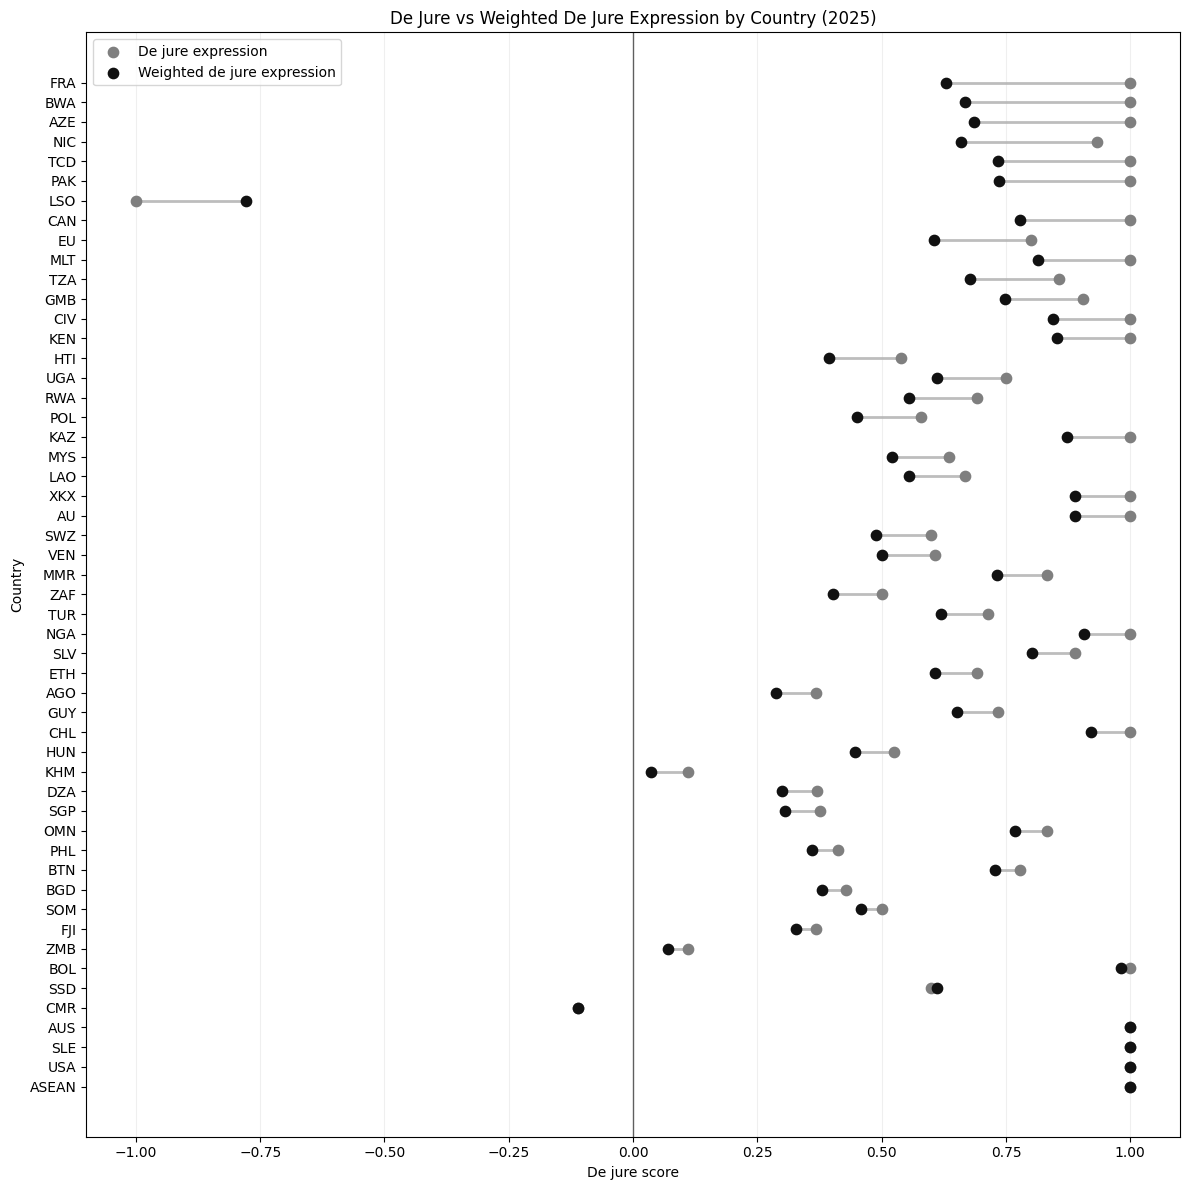

,COUNTRY,iso3,dj_expression,wdj_expression,spread,active_rule_count_total
0,ASEAN,ASEAN,1.000000,1.000000,0.000000,3
1,United States,USA,1.000000,1.000000,0.000000,2
2,Sierra Leone,SLE,1.000000,1.000000,0.000000,7
3,Australia,AUS,1.000000,1.000000,0.000000,1
4,Cameroon,CMR,-0.111111,-0.111111,0.000000,9
5,South Sudan,SSD,0.600000,0.611111,0.011111,15
6,Bolivia,BOL,1.000000,0.981481,0.018519,6
7,Zambia,ZMB,0.111111,0.070988,0.040123,36
8,Fiji,FJI,0.368421,0.327485,0.040936,19
9,Somalia,SOM,0.500000,0.458333,0.041667,8


In [19]:
plot_year = 2025

de_jure_weighted_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "dj_expression",
        "wdj_expression",
    ]]
    .dropna()
    .copy()
)

de_jure_weighted_df["active_rule_count_total"] = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

score_cols = ["dj_expression", "wdj_expression"]
de_jure_weighted_df = de_jure_weighted_df[
    (de_jure_weighted_df[score_cols] != 0).any(axis=1)
].copy()
de_jure_weighted_df["spread"] = (
    de_jure_weighted_df[score_cols].max(axis=1)
    - de_jure_weighted_df[score_cols].min(axis=1)
)

de_jure_weighted_df = de_jure_weighted_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(de_jure_weighted_df))

plt.figure(figsize=(12, 12))

for i, row in de_jure_weighted_df.iterrows():
    x_values = sorted([row["dj_expression"], row["wdj_expression"]])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    de_jure_weighted_df["dj_expression"],
    y_pos,
    color="#7f7f7f",
    s=55,
    label="De jure expression",
    zorder=3,
)
plt.scatter(
    de_jure_weighted_df["wdj_expression"],
    y_pos,
    color="#111111",
    s=55,
    label="Weighted de jure expression",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, de_jure_weighted_df["iso3"])
plt.xlabel("De jure score")
plt.ylabel("Country")
plt.title(f"De Jure vs Weighted De Jure Expression by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

de_jure_weighted_df[[
    "COUNTRY",
    "iso3",
    "dj_expression",
    "wdj_expression",
    "spread",
    "active_rule_count_total",
]]

In [20]:
value_cols = rule_cols

id_cols = [c for c in df.columns if c in ["COUNTRY", "year", "iso3"] or str(c).startswith("Unnamed")]

X_presence = (df[value_cols].fillna(0) != 0).astype(int)

# Use the _new panel's authoritative weighted measures under the old
# analysis column names so the existing EDA code runs unchanged.
weighted_aliases = {
    "de_jure": "dj_expression",
    "weighted_de_jure": "wdj_expression",
    "weighted_de_jure_C": "wdj_citizen",
    "weighted_de_jure_I": "wdj_intermediaries",
    "weighted_de_jure_P": "wdj_press",
    "weighted_de_jure_GOV.PROT": "wdj_govprot",
    "weighted_de_jure_RESTRICTION": "wdj_restriction",
    "weighted_de_jure_OBLIGATION": "wdj_obligation",
}

for target, source in weighted_aliases.items():
    if target not in df.columns and source in df.columns:
        df[target] = df[source]

if "legal_rule_count_total" not in df.columns:
    df["legal_rule_count_total"] = X_presence.sum(axis=1)

if "legal_rule_count_RESTRICTION" not in df.columns:
    restriction_cols = [c for c in value_cols if "_EXPRESS_" in c]
    df["legal_rule_count_RESTRICTION"] = X_presence[restriction_cols].sum(axis=1)

if "legal_rule_count_OBLIGATION" not in df.columns:
    obligation_cols = [
        c for c in value_cols
        if c.startswith(("IM_", "GOV_", "PRESS_", "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_"))
    ]
    df["legal_rule_count_OBLIGATION"] = X_presence[obligation_cols].sum(axis=1)

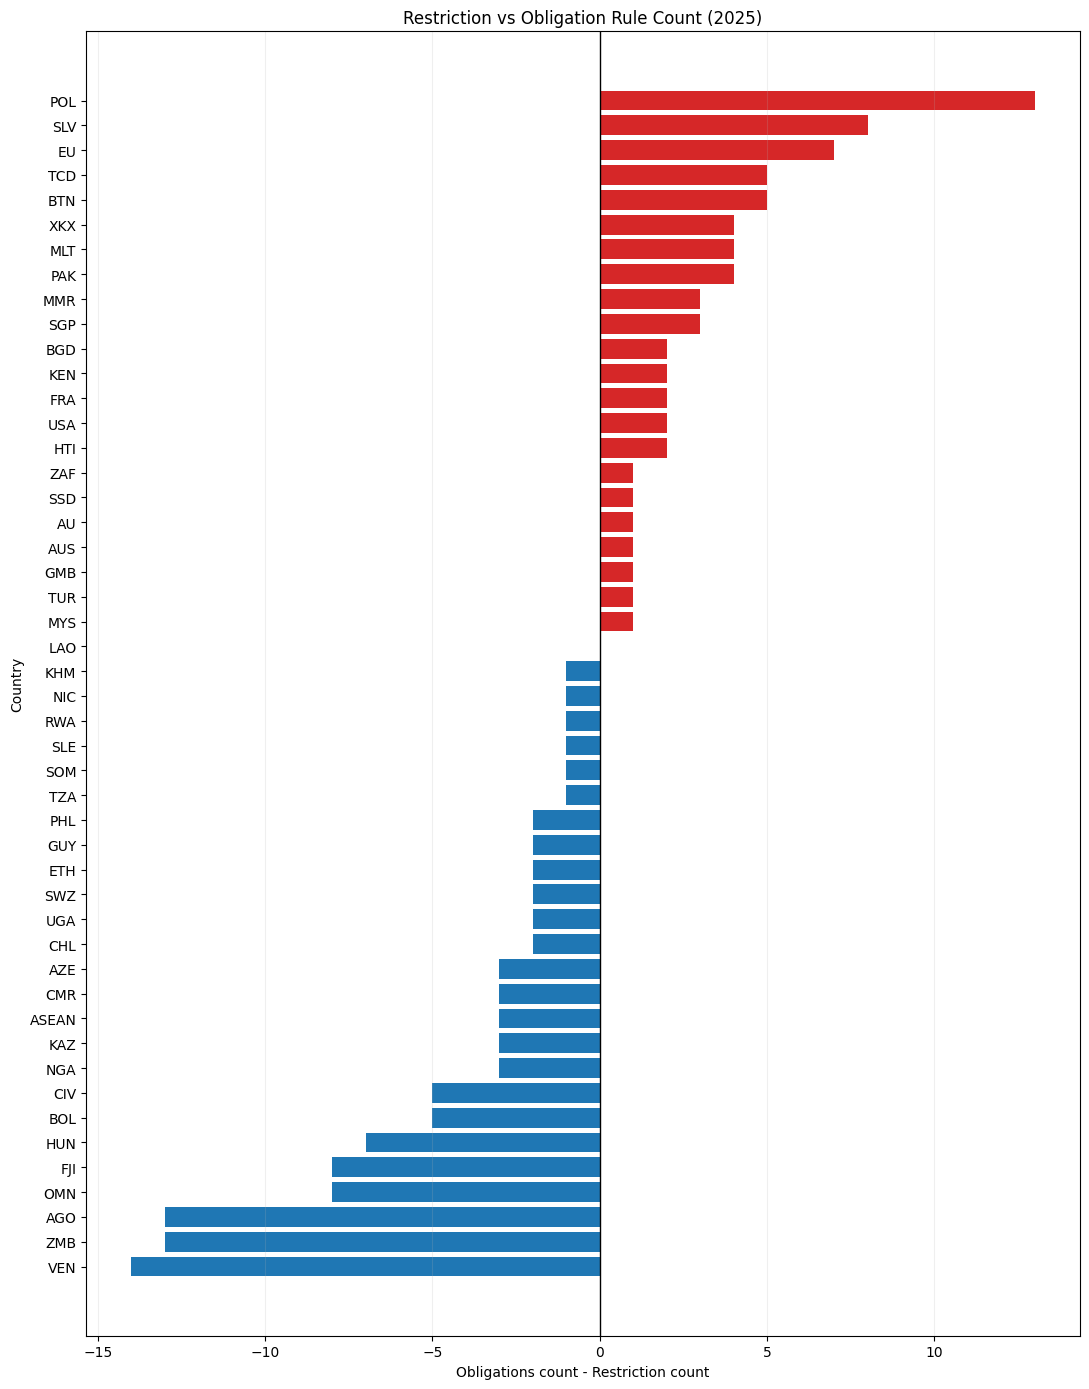

,COUNTRY,iso3,legal_rule_count_RESTRICTION,legal_rule_count_OBLIGATION,divergence,legal_rule_count_total
0,Venezuela,VEN,32,18,-14,56
1,Zambia,ZMB,23,10,-13,36
2,Angola,AGO,13,0,-13,19
3,Oman,OMN,9,1,-8,12
4,Fiji,FJI,13,5,-8,19
5,Hungary,HUN,11,4,-7,21
6,Bolivia,BOL,5,0,-5,6
7,"Côte d""Ivoire",CIV,7,2,-5,10
8,Nigeria,NGA,10,7,-3,18
9,Kazakhstan,KAZ,3,0,-3,7


In [21]:
plot_year = 2025

divergence_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "legal_rule_count_RESTRICTION",
        "legal_rule_count_OBLIGATION",
        "legal_rule_count_total"
    ]]
    .dropna()
    .copy()
)

divergence_df = divergence_df[
    (divergence_df["legal_rule_count_RESTRICTION"] != 0) |
    (divergence_df["legal_rule_count_OBLIGATION"] != 0)
].copy()

divergence_df = divergence_df[divergence_df["iso3"] != "DZA"].copy()

divergence_df["divergence"] = (
    divergence_df["legal_rule_count_OBLIGATION"] - divergence_df["legal_rule_count_RESTRICTION"]
)
divergence_df = divergence_df.sort_values("divergence").reset_index(drop=True)
divergence_df["bar_color"] = np.where(
    divergence_df["divergence"] >= 0,
    "#d62728",
    "#1f77b4"
)

plt.figure(figsize=(11, 14))
plt.barh(
    divergence_df["iso3"],
    divergence_df["divergence"],
    color=divergence_df["bar_color"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Obligations count - Restriction count")
plt.ylabel("Country")
plt.title(f"Restriction vs Obligation Rule Count ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

divergence_df[["COUNTRY", "iso3", "legal_rule_count_RESTRICTION", "legal_rule_count_OBLIGATION", "divergence", "legal_rule_count_total"]]

Legal Density Growth (2000-2025):
Active rules in 2000: 255
Active rules in 2025: 706
Growth factor: 2.8x
Absolute growth: +451 rules



/var/folders/hp/wst3kqps2rjdt2fywq1j141w0000gn/T/ipykernel_79061/3458031383.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.groupby("year", as_index=False)[rule_cols]


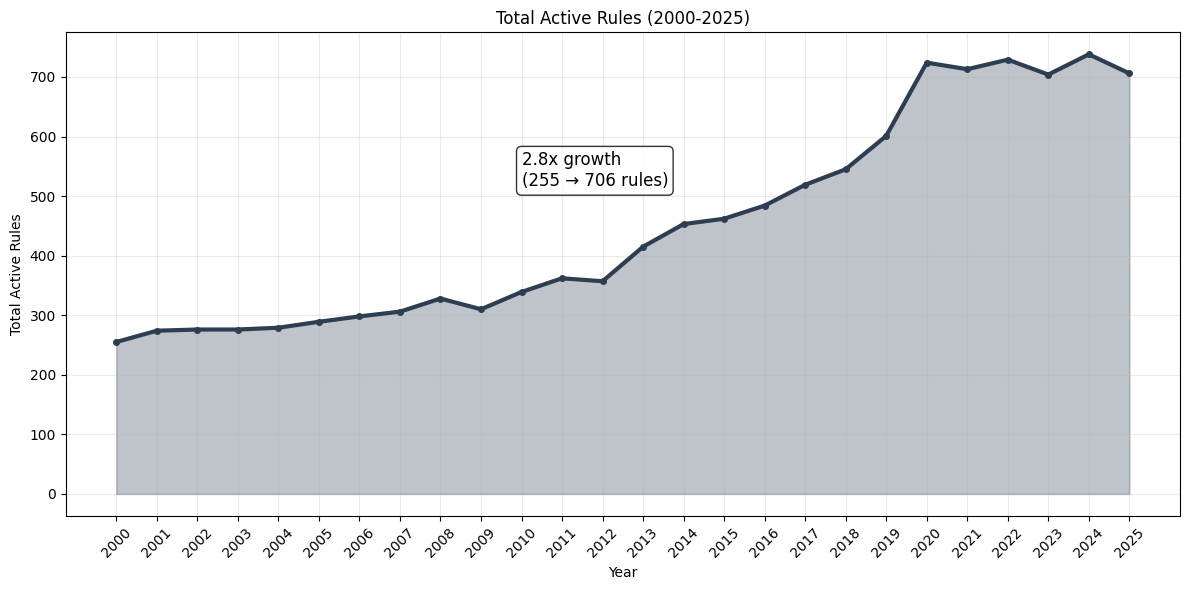


Growth by Actor Type (2000-2025):
            Actor Type  Active 2000  Active 2025  Growth Growth %
         Citizens (C_)          101          316     215  +212.9%
   Press (P_ + PRESS_)           67          113      46   +68.7%
   Internet (I_ + IM_)           54          152      98  +181.5%
Government Protections           15           45      30  +200.0%


In [22]:
# Legal Density Growth: Total Active Rules Over Time
# Shows the explosive growth in regulatory complexity across all actor types

# Calculate total active rules per year
total_rules_over_time = (
    df.groupby("year", as_index=False)[rule_cols]
    .agg(lambda x: (x.fillna(0) != 0).sum())
    .assign(total_active_rules=lambda x: x[rule_cols].sum(axis=1))
    [["year", "total_active_rules"]]
)

# Filter to 2000-2025
total_rules_over_time = total_rules_over_time[total_rules_over_time["year"] >= 2000]

# Calculate growth metrics
start_year = 2000
end_year = 2025
start_rules = total_rules_over_time[total_rules_over_time["year"] == start_year]["total_active_rules"].iloc[0]
end_rules = total_rules_over_time[total_rules_over_time["year"] == end_year]["total_active_rules"].iloc[0]
growth_factor = end_rules / start_rules

print(f"Legal Density Growth (2000-2025):")
print(f"Active rules in {start_year}: {start_rules}")
print(f"Active rules in {end_year}: {end_rules}")
print(f"Growth factor: {growth_factor:.1f}x")
print(f"Absolute growth: +{end_rules - start_rules} rules")
print()

# Plot the growth
plt.figure(figsize=(12, 6))
plt.plot(total_rules_over_time["year"], total_rules_over_time["total_active_rules"], 
         linewidth=3, color="#2c3e50", marker="o", markersize=4)
plt.fill_between(total_rules_over_time["year"], total_rules_over_time["total_active_rules"], 
                 alpha=0.3, color="#2c3e50")
plt.title("Total Active Rules (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Total Active Rules")
plt.grid(True, alpha=0.25)
plt.xticks(total_rules_over_time["year"], rotation=45)

# Add growth annotation
plt.annotate(f'{growth_factor:.1f}x growth\n({start_rules} → {end_rules} rules)', 
             xy=(2010, total_rules_over_time["total_active_rules"].max() * 0.7),
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Show breakdown by actor type growth
print("\nGrowth by Actor Type (2000-2025):")
actor_growth_data = []

for group_name, cols in trend_groups.items():
    start_active = df[df["year"] == start_year][cols].fillna(0).ne(0).sum().sum()
    end_active = df[df["year"] == end_year][cols].fillna(0).ne(0).sum().sum()
    growth = end_active - start_active
    growth_pct = (end_active / max(start_active, 1) - 1) * 100
    
    actor_growth_data.append({
        "Actor Type": group_name,
        f"Active {start_year}": start_active,
        f"Active {end_year}": end_active,
        "Growth": growth,
        "Growth %": f"{growth_pct:+.1f}%"
    })

actor_growth_df = pd.DataFrame(actor_growth_data)
print(actor_growth_df.to_string(index=False))

Citizens - Misinfo: 72, Disinfo: 72, Malinfo: 3
Press - Misinfo: 72, Disinfo: 72, Malinfo: 3
Internet - Misinfo: 72, Disinfo: 72, Malinfo: 3



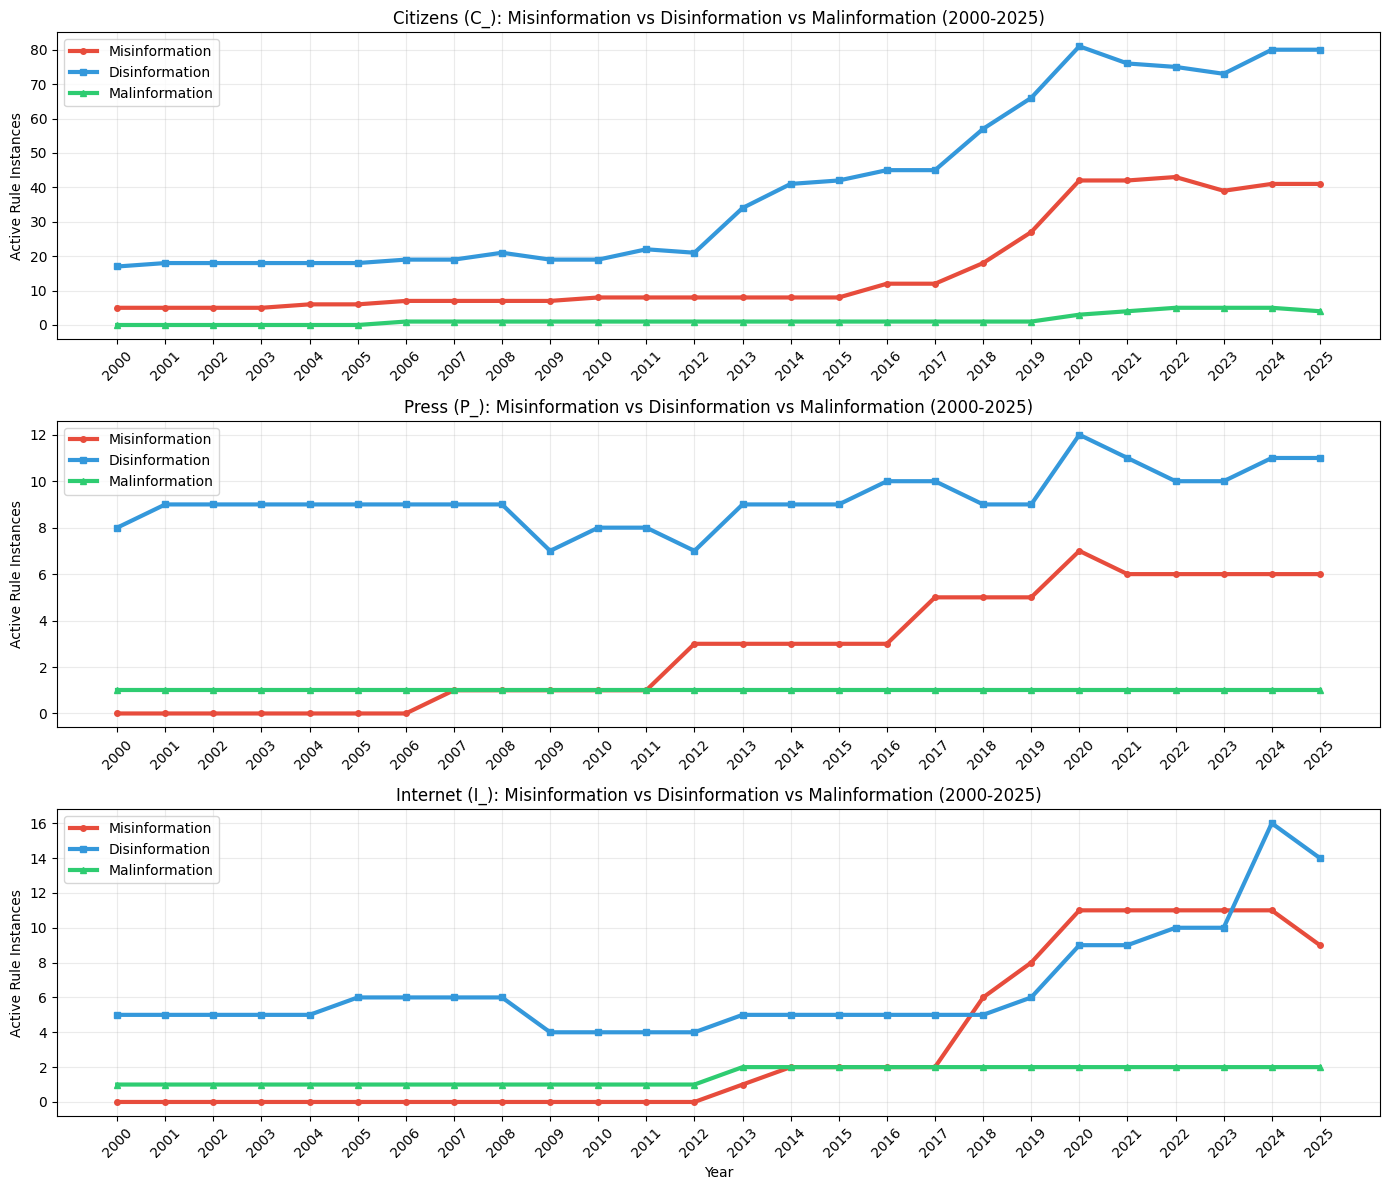


Information Rules by Actor Type (Last 10 Years):
 year  C_Misinfo  C_Disinfo  C_Malinfo  P_Misinfo  P_Disinfo  P_Malinfo  I_Misinfo  I_Disinfo  I_Malinfo
 2016         12         45          1          3         10          1          2          5          2
 2017         12         45          1          5         10          1          2          5          2
 2018         18         57          1          5          9          1          6          5          2
 2019         27         66          1          5          9          1          8          6          2
 2020         42         81          3          7         12          1         11          9          2
 2021         42         76          4          6         11          1         11          9          2
 2022         43         75          5          6         10          1         11         10          2
 2023         39         73          5          6         10          1         11         10          2
 2024

In [23]:
# Misinformation vs Disinformation vs Malinformation Rules by Actor Type (2000-2025)
# Track the emergence and spread across citizens, press, and internet actors

# Identify rules by actor type and information type
c_misinfo_cols = [c for c in rule_cols if c.startswith("C_") and "_MISINFO" in c]
c_disinfo_cols = [c for c in rule_cols if c.startswith("C_") and "_DISINFO" in c]
c_malinfo_cols = [c for c in rule_cols if c.startswith("C_") and "_MALINFO" in c]

p_misinfo_cols = [c for c in rule_cols if c.startswith("P_") and "_MISINFO" in c]
p_disinfo_cols = [c for c in rule_cols if c.startswith("P_") and "_DISINFO" in c]
p_malinfo_cols = [c for c in rule_cols if c.startswith("P_") and "_MALINFO" in c]

i_misinfo_cols = [c for c in rule_cols if c.startswith("I_") and "_MISINFO" in c]
i_disinfo_cols = [c for c in rule_cols if c.startswith("I_") and "_DISINFO" in c]
i_malinfo_cols = [c for c in rule_cols if c.startswith("I_") and "_MALINFO" in c]

print(f"Citizens - Misinfo: {len(c_misinfo_cols)}, Disinfo: {len(c_disinfo_cols)}, Malinfo: {len(c_malinfo_cols)}")
print(f"Press - Misinfo: {len(p_misinfo_cols)}, Disinfo: {len(p_disinfo_cols)}, Malinfo: {len(p_malinfo_cols)}")
print(f"Internet - Misinfo: {len(i_misinfo_cols)}, Disinfo: {len(i_disinfo_cols)}, Malinfo: {len(i_malinfo_cols)}")
print()

# Calculate active instances over time by actor type
info_rules_over_time = pd.DataFrame({"year": df["year"]})

# Citizens
info_rules_over_time["C_Misinfo"] = df[c_misinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["C_Disinfo"] = df[c_disinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["C_Malinfo"] = df[c_malinfo_cols].fillna(0).ne(0).sum(axis=1)

# Press
info_rules_over_time["P_Misinfo"] = df[p_misinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["P_Disinfo"] = df[p_disinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["P_Malinfo"] = df[p_malinfo_cols].fillna(0).ne(0).sum(axis=1)

# Internet
info_rules_over_time["I_Misinfo"] = df[i_misinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["I_Disinfo"] = df[i_disinfo_cols].fillna(0).ne(0).sum(axis=1)
info_rules_over_time["I_Malinfo"] = df[i_malinfo_cols].fillna(0).ne(0).sum(axis=1)

info_rules_over_time = (
    info_rules_over_time
    .groupby("year", as_index=False)
    .sum()
)

# Filter to 2000-2025
info_rules_over_time = info_rules_over_time[info_rules_over_time["year"] >= 2000]

# Plot the comparison by actor type
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

# Citizens plot
ax1.plot(info_rules_over_time["year"], info_rules_over_time["C_Misinfo"], 
         label="Misinformation", color="#e74c3c", linewidth=3, marker="o", markersize=4)
ax1.plot(info_rules_over_time["year"], info_rules_over_time["C_Disinfo"], 
         label="Disinformation", color="#3498db", linewidth=3, marker="s", markersize=4)
ax1.plot(info_rules_over_time["year"], info_rules_over_time["C_Malinfo"], 
         label="Malinformation", color="#2ecc71", linewidth=3, marker="^", markersize=4)
ax1.set_title("Citizens (C_): Misinformation vs Disinformation vs Malinformation (2000-2025)")
ax1.set_ylabel("Active Rule Instances")
ax1.legend()
ax1.grid(True, alpha=0.25)
ax1.set_xticks(info_rules_over_time["year"])
ax1.set_xticklabels(info_rules_over_time["year"], rotation=45)

# Press plot
ax2.plot(info_rules_over_time["year"], info_rules_over_time["P_Misinfo"], 
         label="Misinformation", color="#e74c3c", linewidth=3, marker="o", markersize=4)
ax2.plot(info_rules_over_time["year"], info_rules_over_time["P_Disinfo"], 
         label="Disinformation", color="#3498db", linewidth=3, marker="s", markersize=4)
ax2.plot(info_rules_over_time["year"], info_rules_over_time["P_Malinfo"], 
         label="Malinformation", color="#2ecc71", linewidth=3, marker="^", markersize=4)
ax2.set_title("Press (P_): Misinformation vs Disinformation vs Malinformation (2000-2025)")
ax2.set_ylabel("Active Rule Instances")
ax2.legend()
ax2.grid(True, alpha=0.25)
ax2.set_xticks(info_rules_over_time["year"])
ax2.set_xticklabels(info_rules_over_time["year"], rotation=45)

# Internet plot
ax3.plot(info_rules_over_time["year"], info_rules_over_time["I_Misinfo"], 
         label="Misinformation", color="#e74c3c", linewidth=3, marker="o", markersize=4)
ax3.plot(info_rules_over_time["year"], info_rules_over_time["I_Disinfo"], 
         label="Disinformation", color="#3498db", linewidth=3, marker="s", markersize=4)
ax3.plot(info_rules_over_time["year"], info_rules_over_time["I_Malinfo"], 
         label="Malinformation", color="#2ecc71", linewidth=3, marker="^", markersize=4)
ax3.set_title("Internet (I_): Misinformation vs Disinformation vs Malinformation (2000-2025)")
ax3.set_xlabel("Year")
ax3.set_ylabel("Active Rule Instances")
ax3.legend()
ax3.grid(True, alpha=0.25)
ax3.set_xticks(info_rules_over_time["year"])
ax3.set_xticklabels(info_rules_over_time["year"], rotation=45)

plt.tight_layout()
plt.show()

# Show the data table for recent years
print("\nInformation Rules by Actor Type (Last 10 Years):")
recent_data = info_rules_over_time.tail(10).copy()
recent_data = recent_data.round(0).astype(int)
print(recent_data.to_string(index=False))

Total Misinfo rules: 216
Total Disinfo rules: 216
Total Malinfo rules: 9



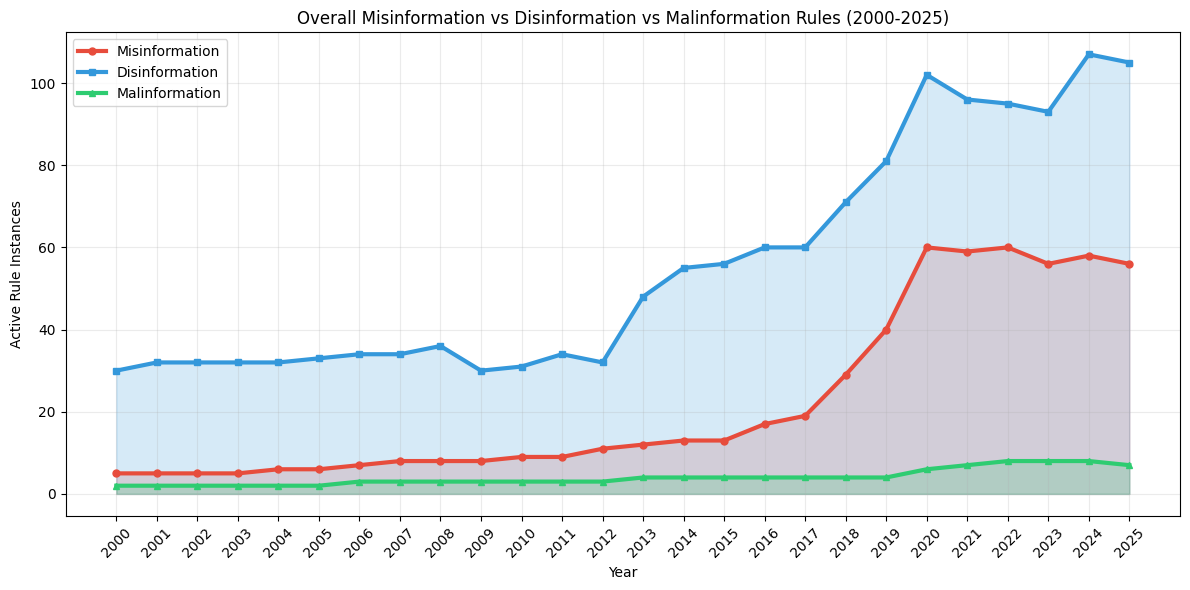


Overall Information Rules Over Time (Last 10 Years):
 year  Misinformation  Disinformation  Malinformation
 2016              17              60               4
 2017              19              60               4
 2018              29              71               4
 2019              40              81               4
 2020              60             102               6
 2021              59              96               7
 2022              60              95               8
 2023              56              93               8
 2024              58             107               8
 2025              56             105               7


In [24]:
# Overall Misinformation vs Disinformation vs Malinformation Rules (2000-2025)
# Combined view across all actor types

# Identify all misinfo, disinfo, and malinfo rules regardless of actor
all_misinfo_cols = [c for c in rule_cols if "_MISINFO" in c]
all_disinfo_cols = [c for c in rule_cols if "_DISINFO" in c]
all_malinfo_cols = [c for c in rule_cols if "_MALINFO" in c]

print(f"Total Misinfo rules: {len(all_misinfo_cols)}")
print(f"Total Disinfo rules: {len(all_disinfo_cols)}")
print(f"Total Malinfo rules: {len(all_malinfo_cols)}")
print()

# Calculate active instances over time
overall_info_rules = pd.DataFrame({"year": df["year"]})

overall_info_rules["Misinformation"] = df[all_misinfo_cols].fillna(0).ne(0).sum(axis=1)
overall_info_rules["Disinformation"] = df[all_disinfo_cols].fillna(0).ne(0).sum(axis=1)
overall_info_rules["Malinformation"] = df[all_malinfo_cols].fillna(0).ne(0).sum(axis=1)

overall_info_rules = (
    overall_info_rules
    .groupby("year", as_index=False)
    .sum()
)

# Filter to 2000-2025
overall_info_rules = overall_info_rules[overall_info_rules["year"] >= 2000]

# Plot the overall comparison
plt.figure(figsize=(12, 6))

plt.plot(overall_info_rules["year"], overall_info_rules["Misinformation"], 
         label="Misinformation", color="#e74c3c", linewidth=3, marker="o", markersize=5)
plt.plot(overall_info_rules["year"], overall_info_rules["Disinformation"], 
         label="Disinformation", color="#3498db", linewidth=3, marker="s", markersize=5)
plt.plot(overall_info_rules["year"], overall_info_rules["Malinformation"], 
         label="Malinformation", color="#2ecc71", linewidth=3, marker="^", markersize=5)

plt.fill_between(overall_info_rules["year"], overall_info_rules["Misinformation"], 
                 alpha=0.2, color="#e74c3c")
plt.fill_between(overall_info_rules["year"], overall_info_rules["Disinformation"], 
                 alpha=0.2, color="#3498db")
plt.fill_between(overall_info_rules["year"], overall_info_rules["Malinformation"], 
                 alpha=0.2, color="#2ecc71")

plt.title("Overall Misinformation vs Disinformation vs Malinformation Rules (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Active Rule Instances")
plt.legend()
plt.grid(True, alpha=0.25)
plt.xticks(overall_info_rules["year"], rotation=45)

plt.tight_layout()
plt.show()

# Show the data table
print("\nOverall Information Rules Over Time (Last 10 Years):")
print(overall_info_rules.tail(10).to_string(index=False))